In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [17]:
df = pd.read_csv("./xyz.csv")
df.head(5)

,Name,Attendance (%),Study Hours/Week,Previous Score,Extracurricular Activities,Final Score
0,Jane Smith,68.73,15.44,83.71,Low,72.58
1,Chris Jones,97.54,13.5,67.65,High,74.82
2,Emily Williams,86.60,15.46,71.73,Low,73.49
3,Anna Moore,79.93,5.06,67.09,High,62.87
4,Beth Taylor,57.80,13.9,50.74,High,56.62


In [18]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head(5)

,name,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,Jane Smith,68.73,15.44,83.71,Low,72.58
1,Chris Jones,97.54,13.5,67.65,High,74.82
2,Emily Williams,86.60,15.46,71.73,Low,73.49
3,Anna Moore,79.93,5.06,67.09,High,62.87
4,Beth Taylor,57.80,13.9,50.74,High,56.62


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        736 non-null    object 
 1   attendance_(%)              736 non-null    float64
 2   study_hours/week            736 non-null    object 
 3   previous_score              736 non-null    float64
 4   extracurricular_activities  736 non-null    object 
 5   final_score                 736 non-null    float64
dtypes: float64(3), object(3)
memory usage: 34.6+ KB


In [31]:
df['study_hours/week'] = pd.to_numeric(df['study_hours/week'], errors='coerce', downcast='float')
print(df.isnull().sum())

name                          0
attendance_(%)                0
study_hours/week              3
previous_score                0
extracurricular_activities    0
final_score                   0
dtype: int64


In [36]:
null_entries = df[df['study_hours/week'].isnull()]
print(null_entries)


             name  attendance_(%)  study_hours/week  previous_score  \
398     Jane Gray           85.51               NaN           87.34   
546      Alex Lee           71.29               NaN           75.98   
647  Katie Carter           58.06               NaN           82.14   

     extracurricular_activities  final_score  
398                           0        80.24  
546                           2        74.24  
647                           2        73.58  


In [37]:
df = df.dropna(subset=['study_hours/week'])

In [38]:
print(df.isnull().sum())

name                          0
attendance_(%)                0
study_hours/week              0
previous_score                0
extracurricular_activities    0
final_score                   0
dtype: int64


In [39]:
label_encoder = LabelEncoder()
activity_mapping = {
    'Low': 0,
    'Moderate': 1,
    'High': 2
}
df['extracurricular_activities'] = df['extracurricular_activities'].map(activity_mapping)
df.head(10)

,name,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,Jane Smith,68.73,15.440000,83.71,NaN,72.58
1,Chris Jones,97.54,13.500000,67.65,NaN,74.82
2,Emily Williams,86.60,15.460000,71.73,NaN,73.49
3,Anna Moore,79.93,5.060000,67.09,NaN,62.87
4,Beth Taylor,57.80,13.900000,50.74,NaN,56.62
5,Michael Smith,57.80,16.790001,79.73,NaN,70.24
6,John Johnson,52.90,22.389999,55.44,NaN,63.98
7,Emma Jones,93.31,12.410000,41.34,NaN,61.05
8,David Taylor,80.06,10.960000,75.50,NaN,70.88
9,Mark Moore,85.40,12.490000,49.74,NaN,63.22


In [40]:
df.describe()

,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
count,733.000000,733.000000,733.00000,0.0,733.000000
mean,72.076276,15.510818,74.89719,NaN,73.413042
std,12.833310,2.622354,10.59302,NaN,6.068034
min,50.280000,5.060000,40.85000,NaN,54.920000
25%,60.660000,13.510000,68.62000,NaN,67.580000
50%,68.010000,15.340000,75.98000,NaN,73.240000
75%,86.090000,17.230000,82.76000,NaN,77.580000
max,99.340000,27.320000,94.45000,NaN,88.720000


In [41]:
df.head()

,name,attendance_(%),study_hours/week,previous_score,extracurricular_activities,final_score
0,Jane Smith,68.73,15.44,83.71,NaN,72.58
1,Chris Jones,97.54,13.50,67.65,NaN,74.82
2,Emily Williams,86.60,15.46,71.73,NaN,73.49
3,Anna Moore,79.93,5.06,67.09,NaN,62.87
4,Beth Taylor,57.80,13.90,50.74,NaN,56.62


In [42]:
student = df.drop('name', axis=1)

In [43]:
print(student.dtypes)

attendance_(%)                float64
study_hours/week              float32
previous_score                float64
extracurricular_activities    float64
final_score                   float64
dtype: object


<Axes: xlabel='previous_score', ylabel='final_score'>

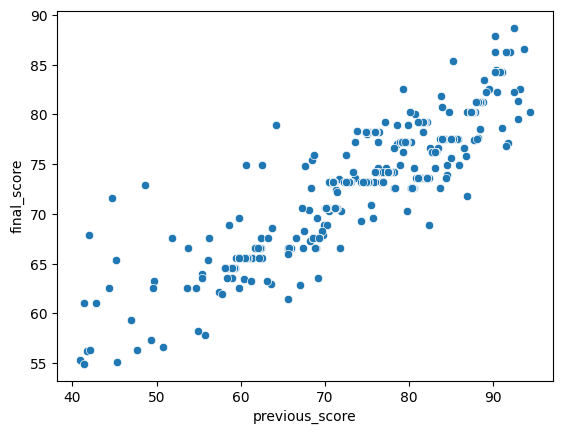

In [44]:
sns.scatterplot(x="previous_score",y="final_score",data=student)

The scatterplot between previous_score and final_score shows that they are somehow linearly realted to each other which means that the current performance of the students can be predicted on the basis of their previous performance.

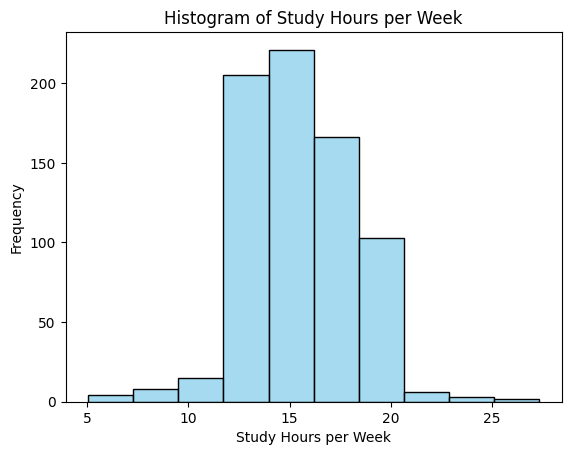

In [49]:
sns.histplot(data=df, x='study_hours/week', bins=10, color='skyblue', edgecolor='black')
plt.title('Histogram of Study Hours per Week')
plt.xlabel('Study Hours per Week')
plt.ylabel('Frequency')
plt.show()

From the above histogram one can easily identify that most of the students studied around 15 hours per week the current semester.

<Axes: >

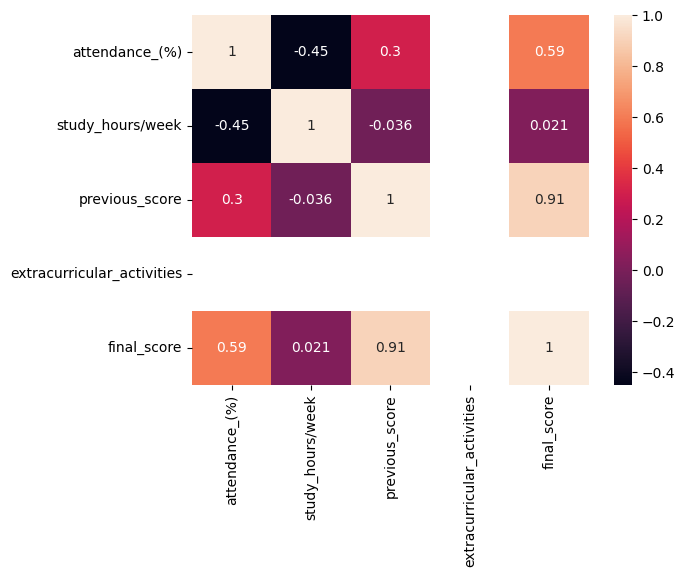

In [45]:
corr_mat = student.corr()
sns.heatmap(corr_mat,annot=True)

From the analysis of heatmap, it was found that previous_score and attendance showed high correlation with final_score which indicated that the current performance of the students greatly rely on their recent performance and their frequency of classes attend.Students not attending the college study more than the students attending the college at their home.